In [8]:
# CELL 2
import os, random, time, math, shutil
from pathlib import Path
from tqdm.notebook import tqdm
import numpy as np
from PIL import Image, ImageFilter, ImageOps
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Sampler
import torchvision.transforms as T
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights

from sklearn.metrics import average_precision_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# device selection (prefer MPS on macOS)
if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# USER CONFIG — tweak as needed
DATA_ROOT = Path("dataset")            # final dataset root (we'll create subfolders here)
SRC_FFHQ = Path("FFHQ_real")           # path where you placed the FFHQ real images
SRC_SD_1024 = Path("stable_diffusion_dataset/1024")   # path containing 'man' and 'women' subfolders
SRC_SD_512 = Path("stable_diffusion_datset/512")   # path containing 'man' and 'women' subfolders
SRC_SD_768 = Path("stable_diffusion_dataset/768")  # path containing 'man' and 'women' subfolders
SRC_GAN = Path("gan_generated")        # folder containing ProGAN/StyleGAN images
TARGET_SIZE = 224                      # model input size (EfficientNet-B2: 260 is default but 224 works well)
MAX_PER_CLASS = 30000                  # max images per class (be conservative for local training)
VALID_RATIO = 0.10                     # fraction for validation
TEST_RATIO = 0.10                      # fraction for test
RANDOM_SEED = SEED
os.makedirs(DATA_ROOT, exist_ok=True)

Device: mps


In [10]:
# CELL 3 - prepare raw dataset from your sources (FINAL & FIXED)
%pip install pillow

from pathlib import Path
from PIL import Image, UnidentifiedImageError

RAW_REAL = DATA_ROOT / "raw" / "real"
RAW_FAKE = DATA_ROOT / "raw" / "fake"
for p in [RAW_REAL, RAW_FAKE]:
    p.mkdir(parents=True, exist_ok=True)

def is_image_file(path: Path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except:
        return False


# ============================================================
# 1. FFHQ REAL IMAGES
# ============================================================
print("Copying real images from:", SRC_FFHQ)

real_files = sorted([
    p for p in SRC_FFHQ.glob("*")
    if p.is_file() and is_image_file(p)
])

print("Found real images:", len(real_files))

real_count = 0
for p in tqdm(real_files, desc="Copy real"):
    if real_count >= MAX_PER_CLASS:
        break
    dst = RAW_REAL / f"real_{real_count:05d}{p.suffix.lower()}"
    shutil.copy(p, dst)
    real_count += 1


# ============================================================
# 2. STABLE DIFFUSION IMAGES (512, 768, 1024 + any subfolders)
# ============================================================

print("\nCopying ALL Stable Diffusion images (512/768/1024)...")

SD_ROOTS = [SRC_SD_512, SRC_SD_768, SRC_SD_1024]

sd_files = []

def collect_all_images(folder: Path):
    """Recursively collect all image files from folder."""
    imgs = []
    if folder.exists():
        for p in folder.rglob("*"):
            if p.is_file() and is_image_file(p):
                imgs.append(p)
    return imgs


# collect images from each SD resolution folder
for sd_root in SD_ROOTS:
    sd_files.extend(collect_all_images(sd_root))

print("Total Stable Diffusion images found:", len(sd_files))

fake_count = 0
for p in tqdm(sd_files, desc="Copy SD fake"):
    if fake_count >= MAX_PER_CLASS:
        break
    dst = RAW_FAKE / f"sd_{fake_count:05d}{p.suffix.lower()}"
    shutil.copy(p, dst)
    fake_count += 1


# ============================================================
# 3. GAN GENERATED IMAGES (3 subfolders)
# ============================================================

print("\nCopying GAN-generated images...")

GAN_SUBFOLDERS = [
    SRC_GAN / "ProGAN_128x128",
    SRC_GAN / "StyleGAN2_256x256",
    SRC_GAN / "StyleGAN3_256x256",
]

gan_files = []
for folder in GAN_SUBFOLDERS:
    gan_files.extend(collect_all_images(folder))

print("Total GAN images found:", len(gan_files))

for p in tqdm(gan_files, desc="Copy GAN fake"):
    if fake_count >= MAX_PER_CLASS:
        break
    dst = RAW_FAKE / f"gan_{fake_count:05d}{p.suffix.lower()}"
    shutil.copy(p, dst)
    fake_count += 1


# ============================================================
# SUMMARY
# ============================================================

print(f"\nFINAL → REAL: {real_count}   FAKE: {fake_count}")

Note: you may need to restart the kernel to use updated packages.
Copying real images from: FFHQ_real
Found real images: 70000


Copy real:   0%|          | 0/70000 [00:00<?, ?it/s]


Copying ALL Stable Diffusion images (512/768/1024)...
Total Stable Diffusion images found: 6000


Copy SD fake:   0%|          | 0/6000 [00:00<?, ?it/s]


Copying GAN-generated images...
Total GAN images found: 21300


Copy GAN fake:   0%|          | 0/21300 [00:00<?, ?it/s]


FINAL → REAL: 30000   FAKE: 27300


In [11]:
# CELL 4 - create splits (balanced)
import math, random
random.seed(RANDOM_SEED)

RAW_REAL_FILES = sorted(list(RAW_REAL.glob("*")))
RAW_FAKE_FILES = sorted(list(RAW_FAKE.glob("*")))

n_real = len(RAW_REAL_FILES)
n_fake = len(RAW_FAKE_FILES)
n = min(n_real, n_fake, MAX_PER_CLASS)
print("Using", n, "images per class for balanced dataset")

# compute splits
n_test = int(math.floor(n * TEST_RATIO))
n_valid = int(math.floor(n * VALID_RATIO))
n_train = n - n_valid - n_test
print("Train/Valid/Test per class:", n_train, n_valid, n_test)

# sample
random.shuffle(RAW_REAL_FILES)
random.shuffle(RAW_FAKE_FILES)
real_sel = RAW_REAL_FILES[:n]
fake_sel = RAW_FAKE_FILES[:n]

def split_and_copy(files, label, label_name):
    train_dir = DATA_ROOT / "train" / label_name
    valid_dir = DATA_ROOT / "valid" / label_name
    test_dir  = DATA_ROOT / "test"  / label_name
    for d in [train_dir, valid_dir, test_dir]:
        d.mkdir(parents=True, exist_ok=True)
    # splits
    train_files = files[:n_train]
    valid_files = files[n_train:n_train+n_valid]
    test_files  = files[n_train+n_valid:n_train+n_valid+n_test]

    for i, src in enumerate(train_files):
        dst = train_dir / src.name
        if not dst.exists(): shutil.copy(src, dst)
    for i, src in enumerate(valid_files):
        dst = valid_dir / src.name
        if not dst.exists(): shutil.copy(src, dst)
    for i, src in enumerate(test_files):
        dst = test_dir / src.name
        if not dst.exists(): shutil.copy(src, dst)

split_and_copy(real_sel, 0, "real")
split_and_copy(fake_sel, 1, "fake")

print("Dataset folders created:")
print("train/real:", len(list((DATA_ROOT/"train"/"real").glob("*"))))
print("train/fake:", len(list((DATA_ROOT/"train"/"fake").glob("*"))))
print("valid/real:", len(list((DATA_ROOT/"valid"/"real").glob("*"))))
print("valid/fake:", len(list((DATA_ROOT/"valid"/"fake").glob("*"))))
print("test/real:", len(list((DATA_ROOT/"test"/"real").glob("*"))))
print("test/fake:", len(list((DATA_ROOT/"test"/"fake").glob("*"))))

Using 27300 images per class for balanced dataset
Train/Valid/Test per class: 21840 2730 2730
Dataset folders created:
train/real: 21840
train/fake: 21840
valid/real: 2730
valid/fake: 2730
test/real: 2730
test/fake: 2730


In [12]:
# CELL 5 - augmentation functions and custom transforms
import numpy as np
from io import BytesIO

class RandomJPEG:
    def __init__(self, p=0.2, q_min=30, q_max=95):
        self.p = p
        self.q_min = q_min
        self.q_max = q_max
    def __call__(self, img: Image.Image):
        if random.random() > self.p:
            return img
        q = random.randint(self.q_min, self.q_max)
        buf = BytesIO()
        img.save(buf, format="JPEG", quality=q)
        buf.seek(0)
        return Image.open(buf).convert("RGB")

class RandomGaussianBlur:
    def __init__(self, p=0.2, max_sigma=2.5):
        self.p = p
        self.max_sigma = max_sigma
    def __call__(self, img: Image.Image):
        if random.random() > self.p:
            return img
        sigma = random.uniform(0.1, self.max_sigma)
        return img.filter(ImageFilter.GaussianBlur(radius=sigma))

class RandomPixelShufflePatch:
    """Randomly shuffle pixels inside small patches to disturb local structure."""
    def __init__(self, p=0.15, patch_size=8):
        self.p = p
        self.patch_size = patch_size
    def __call__(self, img: Image.Image):
        if random.random() > self.p:
            return img
        arr = np.array(img)
        h, w, c = arr.shape
        ps = self.patch_size
        # choose random patch
        y = random.randint(0, max(0, h-ps))
        x = random.randint(0, max(0, w-ps))
        patch = arr[y:y+ps, x:x+ps].copy()
        flat = patch.reshape(-1, c)
        np.random.shuffle(flat)
        arr[y:y+ps, x:x+ps] = flat.reshape(ps, ps, c)
        return Image.fromarray(arr)

class RandomDownscaleUpscale:
    def __init__(self, p=0.2, scale_min=0.5):
        self.p = p
        self.scale_min = scale_min
    def __call__(self, img: Image.Image):
        if random.random() > self.p:
            return img
        w, h = img.size
        scale = random.uniform(self.scale_min, 0.9)
        neww, newh = max(1, int(w*scale)), max(1, int(h*scale))
        img_small = img.resize((neww,newh), resample=Image.BILINEAR)
        img_up = img_small.resize((w,h), resample=Image.BILINEAR)
        return img_up

class RandomNoise:
    def __init__(self, p=0.2, std_max=0.05):
        self.p = p
        self.std_max = std_max
    def __call__(self, img: Image.Image):
        if random.random() > self.p:
            return img
        arr = np.array(img).astype(np.float32)/255.0
        std = random.uniform(0.005, self.std_max)
        noise = np.random.randn(*arr.shape) * std
        arr = np.clip(arr + noise, 0, 1)
        arr = (arr*255).astype(np.uint8)
        return Image.fromarray(arr)

In [13]:
# CELL 6 - dataset class and balanced sampler
class RealFakeDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.folder = Path(folder)
        self.items = []
        for lbl_name, lbl in [("real", 0), ("fake", 1)]:
            dirp = self.folder / lbl_name
            if not dirp.exists():
                continue
            for p in sorted(dirp.glob("*")):
                if p.suffix.lower() in [".jpg",".jpeg",".png"]:
                    self.items.append((str(p), lbl))
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, lbl = self.items[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, lbl

class BalancedBatchSampler(Sampler):
    def __init__(self, labels, batch_size):
        assert batch_size % 2 == 0
        self.batch_size = batch_size
        self.labels = np.array(labels)
        self.real_idx = list(np.where(self.labels==0)[0])
        self.fake_idx = list(np.where(self.labels==1)[0])
        random.shuffle(self.real_idx)
        random.shuffle(self.fake_idx)
        self.ptr_r = 0
        self.ptr_f = 0
        self.num_batches = (min(len(self.real_idx), len(self.fake_idx)) * 2) // batch_size
    def __iter__(self):
        for _ in range(self.num_batches):
            batch = []
            half = self.batch_size//2
            for _ in range(half):
                if self.ptr_r >= len(self.real_idx):
                    random.shuffle(self.real_idx); self.ptr_r = 0
                batch.append(self.real_idx[self.ptr_r]); self.ptr_r += 1
                if self.ptr_f >= len(self.fake_idx):
                    random.shuffle(self.fake_idx); self.ptr_f = 0
                batch.append(self.fake_idx[self.ptr_f]); self.ptr_f += 1
            random.shuffle(batch)
            yield batch
    def __len__(self):
        return self.num_batches

In [14]:
# CELL 7 - transforms and dataloaders
train_transform = T.Compose([
    RandomGaussianBlur(p=0.2, max_sigma=2.0),
    RandomJPEG(p=0.2, q_min=25, q_max=95),
    RandomPixelShufflePatch(p=0.12, patch_size=8),
    RandomDownscaleUpscale(p=0.15, scale_min=0.5),
    RandomNoise(p=0.15, std_max=0.06),
    T.RandomHorizontalFlip(),
    T.RandomResizedCrop(TARGET_SIZE, scale=(0.7,1.0)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

val_transform = T.Compose([
    T.Resize(int(TARGET_SIZE*1.15)),
    T.CenterCrop(TARGET_SIZE),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

train_ds = RealFakeDataset(DATA_ROOT/"train", transform=train_transform)
val_ds   = RealFakeDataset(DATA_ROOT/"valid", transform=val_transform)
test_ds  = RealFakeDataset(DATA_ROOT/"test",  transform=val_transform)

print("Dataset sizes:", len(train_ds), len(val_ds), len(test_ds))

# prepare Balanced sampler for train
train_labels = [lbl for (_, lbl) in train_ds.items]
batch_size = 32  # must be even
sampler = BalancedBatchSampler(train_labels, batch_size=batch_size)

# DataLoaders (num_workers=0 for macOS safety)
train_loader = DataLoader(train_ds, batch_sampler=sampler, num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=False)

Dataset sizes: 43680 5460 5460


In [15]:
# CELL 8 - model + optimizer
weights = EfficientNet_B2_Weights.IMAGENET1K_V1
model = efficientnet_b2(weights=weights)

# replace classifier
if hasattr(model, "classifier"):
    in_f = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_f, 2)
else:
    # fallback (rare)
    model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.2, patience=3)

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /Users/snehpatel/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [01:06<00:00, 552kB/s] 


In [16]:
# CELL 9 - training loop
n_epochs = 1
best_val_ap = 0.0
log_every = 50

for epoch in range(1, n_epochs+1):
    model.train()
    running_loss = 0.0
    t0 = time.time()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch}/{n_epochs}")
    for i, batch in pbar:
        imgs, labels = batch
        imgs = imgs.to(device)
        labels = labels.to(device, dtype=torch.long)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() 
        if (i+1) % log_every == 0:
            pbar.set_postfix({"loss": f"{running_loss/log_every:.4f}"})
            running_loss = 0.0

    # Validation
    model.eval()
    y_true, y_score = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            labels = labels.to(device, dtype=torch.long)
            out = model(imgs)
            probs = torch.softmax(out, dim=1)[:,1]
            y_true.extend(labels.cpu().numpy())
            y_score.extend(probs.cpu().numpy())

    val_ap = average_precision_score(y_true, y_score) if len(set(y_true))>1 else 0.0
    val_preds = [1 if p>=0.5 else 0 for p in y_score]
    val_acc = accuracy_score(y_true, val_preds)

    print(f"Epoch {epoch} — Val AP: {val_ap:.4f}, Val Acc: {val_acc:.4f}, time: {time.time()-t0:.1f}s")

    scheduler.step(val_ap)

    # Save best
    if val_ap > best_val_ap:
        best_val_ap = val_ap
        fname = f"best_effb2_gen_{epoch}_ap{val_ap:.4f}.pth"
        torch.save({"epoch": epoch, "model_state": model.state_dict(), "val_ap": val_ap}, fname)
        print("Saved checkpoint:", fname)

Epoch 1/1:   0%|          | 0/1365 [00:00<?, ?it/s]

Epoch 1 — Val AP: 1.0000, Val Acc: 0.9998, time: 6445.0s
Saved checkpoint: best_effb2_gen_1_ap1.0000.pth
Saved checkpoint: best_effb2_gen_1_ap1.0000.pth


Loaded checkpoint: best_effb2_gen_1_ap1.0000.pth


Testing:   0%|          | 0/86 [00:00<?, ?it/s]

Test AP: 1.0000  Test Acc: 0.9998


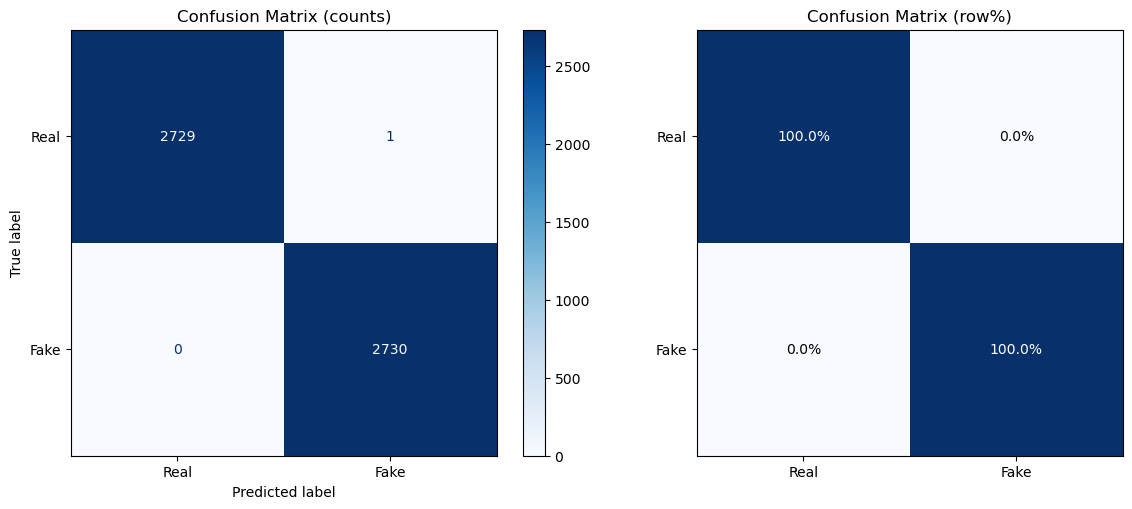

In [17]:
# CELL 10 - test evaluation and confusion matrix
# load best checkpoint if exists (optional: pick the highest val_ap file)
ckpt_files = sorted([f for f in os.listdir('.') if f.startswith("best_effb2_gen_") and f.endswith(".pth")])
if ckpt_files:
    ckpt = torch.load(ckpt_files[-1], map_location=device)
    model.load_state_dict(ckpt["model_state"])
    print("Loaded checkpoint:", ckpt_files[-1])
else:
    print("No checkpoint found. Using current model weights.")

model.eval()
y_true, y_pred, y_score = [], [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        imgs = imgs.to(device)
        labels = labels.to(device, dtype=torch.long)
        out = model(imgs)
        probs = torch.softmax(out, dim=1)[:,1]
        preds = (probs >= 0.5).long()
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_score.extend(probs.cpu().numpy())

test_ap = average_precision_score(y_true, y_score) if len(set(y_true))>1 else 0.0
test_acc = accuracy_score(y_true, y_pred)
print(f"Test AP: {test_ap:.4f}  Test Acc: {test_acc:.4f}")

# Confusion matrix (counts and percentages)
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real","Fake"])
fig, ax = plt.subplots(1,2, figsize=(12,5))
disp.plot(cmap="Blues", ax=ax[0])
ax[0].set_title("Confusion Matrix (counts)")

# percentages
cm_perc = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
im = ax[1].imshow(cm_perc, cmap="Blues")
ax[1].set_xticks([0,1]); ax[1].set_yticks([0,1])
ax[1].set_xticklabels(["Real","Fake"]); ax[1].set_yticklabels(["Real","Fake"])
for i in range(2):
    for j in range(2):
        ax[1].text(j, i, f"{cm_perc[i,j]*100:.1f}%", ha="center", va="center", color="white" if cm_perc[i,j]>0.5 else "black")
ax[1].set_title("Confusion Matrix (row%)")
plt.tight_layout()
plt.show()